<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_2_4_3_MLR_Ames_Part3_Revised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLR Predicting Housing Prices in Ames Iowa: Part 3
## Regularization
Author: Brad Sheese

To recap:

- Exercise 1: Focused on data cleaning and feature reduction for the Ames Dataset.

- Exercise 2: Applied forward and backward feature selection incorporating both linear and non-linear (polynomial) features.

This notebook:

- Introduces regularization techniques—specifically Lasso, Ridge, and Elastic Net—to help prevent overfitting and improve model generalization.


Data Source:
-  http://jse.amstat.org/v19n3/decock/AmesHousing.txt

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data source
url = 'https://raw.githubusercontent.com/bsheese/CSDS125ExampleData/master/data_housing_ames.txt'

# Loading the dataframe
df_raw = pd.read_csv(url, sep='\t')

# Initial cleaning: remove extreme outliers per the author's recommendation, large houses sold for little money due to inheritance
df = df_raw.loc[df_raw['Gr Liv Area'] < 4000, :].copy()

# Fix Garage Year Built in the Future
df.loc[df['Garage Yr Blt'] > 2010, 'Garage Yr Blt'] = 2010

# helper functions
def safe_drop(df: pd.DataFrame, drop_list: list[str]) -> pd.DataFrame:
  """
  Safely drops columns from a Pandas DataFrame if they exist.

  Args:
    df (pd.DataFrame): The input DataFrame.
    drop_list (list[str]): A list of column names to attempt to drop.

  Returns:
    pd.DataFrame: The DataFrame with specified columns dropped (if they existed).
  """
  # Filter drop_list to only include columns that exist in the DataFrame
  existing_cols_to_drop = [col for col in drop_list if col in df.columns]

  # Drop the columns if there are any to drop
  if existing_cols_to_drop:
    df = df.drop(existing_cols_to_drop, axis=1)
  return df

# compressed cleaning code from Part 1

print(df.shape)

if 'garage_attached' not in df.columns:
  df['garage_attached'] = np.where(df['Garage Type'] == 'Attchd', 1, 0)
if 'garage_unfinished' not in df.columns:
  df['garage_unfinished'] = np.where(df['Garage Finish'] != 'Unf', 1, 0)

d1 = ['Order', 'PID']
d2 = ['Pool QC', 'Pool Area', 'Misc Feature', 'Misc Val']
d3 = ['Alley', 'Fence', 'Mas Vnr Type', 'Bsmt Qual', 'Bsmt Cond', \
      'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Fireplace Qu', \
      'Neighborhood', 'MS Subclass', 'Mo Sold', 'Kitchen Qual', 'Exter Qual' \
      'Heating QC']
d4 = ['Garage Qual', 'Garage Cond', 'Garage Type', 'Garage Finish']
d5 = ['Street', 'Land Contour', 'Utilities', \
      'Land Slope', 'Condition 1', 'Condition 2',\
      'Roof Matl', 'Exter Cond', 'Heating', 'Central Air', \
      'Electrical', 'Functional', 'Paved Drive', "Sale Type"]

df = safe_drop(df, d1 + d2 + d3 + d4 + d5)

for col in df.select_dtypes(include=['object']).columns:
  if df[col].value_counts(normalize=True, dropna=False).max() > 0.50:
    top_value = (df[col].value_counts(normalize=True, dropna=False).index[0])
    df[col + '_' + top_value] = np.where(df[col] == top_value, 1, 0)
    df = safe_drop(df, [col])

df.loc[~df['Foundation'].isin(['PConc', 'CBlock']), 'Foundation'] = 'Other'

df = safe_drop(df, ['Exterior 1st', 'Exterior 2nd'])

for col in df.select_dtypes('object').columns:
  df[col] = df[col].astype('category')

for col in df.columns:
  if df[col].value_counts().shape[0] == 2:
    df[col] = df[col].astype('bool')

for col in df.select_dtypes(include=np.number).columns:
  if df[col].value_counts(normalize=True, dropna=False).max() > 0.90:
    df = safe_drop(df, [col])

for col in df.select_dtypes(include=np.number).columns:
  if df[col].value_counts(normalize=True, dropna=False).max() > 0.80:
    if len(df[col].unique()) > 2:
      df[col] = np.where(df[col] > 0, 1, 0)
    df[col] = df[col].astype('boolean')

df = safe_drop(df, ['Mas Vnr Area'])

num_cols_with_na = df.select_dtypes(include=np.number).columns[df.select_dtypes(include=np.number).isnull().any()].tolist()
for col in num_cols_with_na:
    df[col] = df[col].fillna(df[col].median())

df = pd.get_dummies(df, columns=df.select_dtypes(include='category').columns, drop_first=True)

print(df.shape)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2925 entries, 0 to 2929
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   MS SubClass            2925 non-null   int64  
 1   Lot Frontage           2925 non-null   float64
 2   Lot Area               2925 non-null   int64  
 3   Overall Qual           2925 non-null   int64  
 4   Overall Cond           2925 non-null   int64  
 5   Year Built             2925 non-null   int64  
 6   Year Remod/Add         2925 non-null   int64  
 7   BsmtFin SF 1           2925 non-null   float64
 8   BsmtFin SF 2           2925 non-null   boolean
 9   Bsmt Unf SF            2925 non-null   float64
 10  Total Bsmt SF          2925 non-null   float64
 11  1st Flr SF             2925 non-null   int64  
 12  2nd Flr SF             2925 non-null   int64  
 13  Gr Liv Area            2925 non-null   int64  
 14  Bsmt Full Bath         2925 non-null   float64
 15  Full Bath

# Feature Selection and Evaluation Function

In [ ]:
from typing import Dict, Any, Optional
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def perform_feature_selection_and_evaluation(
    X: pd.DataFrame,
    y: pd.Series,
    model_type: str = 'ols',
    alpha: float = 1.0,
    l1_ratio: float = 0.5,
    selection_direction: str = 'forward',
    cv_folds: int = 5
) -> Dict[str, Any]:
    """
    Performs feature selection and evaluates a regression model using cross-validation.

    Args:
        X (pd.DataFrame): Independent variables.
        y (pd.Series): Dependent variable.
        model_type (str): 'ols', 'lasso', 'ridge', or 'elasticnet'.
        alpha (float): Regularization strength for Lasso, Ridge, and ElasticNet.
                       Higher values = stronger penalty. (Ignored for 'ols').
        l1_ratio (float): The ElasticNet mixing parameter (0.0 to 1.0).
                          0 = Ridge, 1 = Lasso. (Ignored for other models).
        selection_direction (str): 'forward' or 'backward' for OLS SequentialFeatureSelector.
        cv_folds (int): Number of cross-validation folds.

    Returns:
        dict: A dictionary containing the fitted pipeline, selected feature names, and CV metrics.
    """
    model_type = model_type.lower()

    # 1. Build a Pipeline based on the requested model type
    if model_type == 'ols':
        # OLS requires a separate step to handle feature selection
        pipeline_steps =[
            ('scaler', StandardScaler()),
            ('selector', SequentialFeatureSelector(
                LinearRegression(),
                n_features_to_select='auto',
                direction=selection_direction,
                cv=cv_folds
            )),
            ('model', LinearRegression())
        ]
    elif model_type == 'lasso':
        # Lasso handles feature selection internally via the L1 penalty
        pipeline_steps =[
            ('scaler', StandardScaler()),
            ('model', Lasso(alpha=alpha, random_state=42))
        ]
    elif model_type == 'ridge':
        # Ridge penalizes large coefficients but keeps all features (L2 penalty)
        pipeline_steps =[
            ('scaler', StandardScaler()),
            ('model', Ridge(alpha=alpha, random_state=42))
        ]
    elif model_type == 'elasticnet':
        # ElasticNet combines both L1 and L2 penalties
        pipeline_steps =[
            ('scaler', StandardScaler()),
            ('model', ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42))
        ]
    else:
        raise ValueError("model_type must be 'ols', 'lasso', 'ridge', or 'elasticnet'")

    pipeline = Pipeline(pipeline_steps)

    # 2. Perform Cross-Validation
    scoring_metrics =['r2', 'neg_mean_squared_error']
    cv_results = cross_validate(pipeline, X, y, cv=cv_folds, scoring=scoring_metrics)

    cv_r2 = cv_results['test_r2']
    cv_mse = -cv_results['test_neg_mean_squared_error'] # Negating to make it positive

    print(f"--- Model Evaluation ({model_type.upper()}) ---")
    print(f"Cross-validated R-squared: {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
    print(f"Cross-validated MSE:       {cv_mse.mean():.4f} ± {cv_mse.std():.4f}\n")

    # 3. Fit the pipeline on the ENTIRE dataset to get final features and coefficients
    pipeline.fit(X, y)
    final_model = pipeline.named_steps['model']

    # 4. Extract features and formatted outputs based on the algorithm
    print(f"Intercept: {final_model.intercept_:.4f}\n")

    if model_type == 'ols':
        print(f"Standardized Coefficients (using {selection_direction} selection):")
        final_selector = pipeline.named_steps['selector']
        selected_mask = final_selector.get_support()

        # OLS drops features completely from the array
        selected_feature_names = X.columns[selected_mask].tolist()
        display_names = selected_feature_names
        display_coefs = final_model.coef_

    else:
        # Regularized models process all features, but shrink some to exactly 0.0
        # For display, we want to show all features so students can see the 0.0s
        param_str = f"alpha={alpha}" + (f", l1_ratio={l1_ratio}" if model_type == 'elasticnet' else "")
        print(f"Standardized Coefficients (using {model_type.capitalize()} Regularization | {param_str}):")

        display_names = X.columns.tolist()
        display_coefs = final_model.coef_

        # Determine which features survived the penalty (non-zero coefficients)
        # Using np.isclose to handle tiny floating point inaccuracies
        selected_feature_names =[
            name for name, coef in zip(display_names, display_coefs) if not np.isclose(coef, 0.0)
        ]

    # Print the coefficients neatly
    if display_names:
        max_feature_len = max(len(feature) for feature in display_names)
        for name, coef in zip(display_names, display_coefs):
            # Highlight features that were completely dropped by Lasso/ElasticNet
            if np.isclose(coef, 0.0):
                print(f"\t{name.ljust(max_feature_len)}:\t {coef:>7.2f}  <-- Dropped")
            else:
                print(f"\t{name.ljust(max_feature_len)}:\t {coef:>7.2f}")
    else:
        print("\tNo features selected.")

    print(f"\nTotal Features Kept: {len(selected_feature_names)} out of {len(X.columns)}")

    # 5. Return the metrics
    return {
        'model_pipeline': pipeline,
        'selected_features': selected_feature_names,
        'cv_r2_mean': cv_r2.mean(),
        'cv_r2_std': cv_r2.std(),
        'cv_mse_mean': cv_mse.mean(),
        'cv_mse_std': cv_mse.std()
    }

## Model Work-Flow Function

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

def run_modeling_workflow(
    X: pd.DataFrame,
    y: pd.Series,
    model_type: str = 'ols',
    alpha: float = 1.0,
    l1_ratio: float = 0.5,
    test_size: float = 0.20,
    random_state: int = 42,
    selection_direction: str = 'forward',
    cv_folds: int = 5,
    plot_residuals: bool = True
) -> Dict[str, Any]:
    """
    Encapsulates the entire MLR modeling workflow including train-test split,
    feature selection/regularization, model training, evaluation, and residual plotting.

    Args:
        X (pd.DataFrame): Independent variables.
        y (pd.Series): Dependent variable.
        model_type (str): 'ols', 'lasso', 'ridge', or 'elasticnet'.
        alpha (float): Regularization strength for Lasso, Ridge, and ElasticNet.
        l1_ratio (float): The ElasticNet mixing parameter (0.0 to 1.0).
        test_size (float): The proportion of the dataset to include in the test split.
        random_state (int): Seed used by the random number generator for reproducibility.
        selection_direction (str): 'forward' or 'backward' for OLS SequentialFeatureSelector.
        cv_folds (int): Number of cross-validation folds.
        plot_residuals (bool): Whether to plot residuals.

    Returns:
        dict: A dictionary containing final test metrics, selected features,
              the fitted pipeline, residuals, and test predictions.
    """

    # 1. TRAIN-TEST SPLIT
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # 2. CROSS-VALIDATION & FEATURE SELECTION/REGULARIZATION
    print(f"--- Running {model_type.upper()} Cross-Validation on Training Data ---")
    results = perform_feature_selection_and_evaluation(
        X=X_train,
        y=y_train,
        model_type=model_type,
        alpha=alpha,
        l1_ratio=l1_ratio,
        selection_direction=selection_direction,
        cv_folds=cv_folds
    )

    final_model = results['model_pipeline']
    selected_features = results['selected_features']

    # 3. FINAL EVALUATION ON UNSEEN TEST DATA
    print("\n--- Running Final Evaluation on Unseen Test Data ---")
    test_predictions = final_model.predict(X_test)

    final_r2 = r2_score(y_test, test_predictions)
    final_mse = mean_squared_error(y_test, test_predictions)

    print(f"Final Test R-squared: {final_r2:.4f}")
    print(f"Final Test MSE:       {final_mse:.4f}")

    # 4. RESIDUAL ANALYSIS
    residuals = y_test - test_predictions

    if plot_residuals:
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        sns.histplot(residuals, kde=True)
        plt.title('Histogram of Residuals')
        plt.xlabel('Residual Value')
        plt.ylabel('Frequency')

        plt.subplot(1, 2, 2)
        sns.scatterplot(x=test_predictions, y=residuals)
        plt.axhline(y=0, color='r', linestyle='--')
        plt.title('Residuals vs. Predicted Values')
        plt.xlabel('Predicted Values')
        plt.ylabel('Residuals')

        plt.tight_layout()
        plt.show()

    return {
        'final_r2': final_r2,
        'final_mse': final_mse,
        'selected_features': selected_features,
        'model_pipeline': final_model,
        'residuals': residuals,
        'test_predictions': test_predictions,
        'cv_r2_mean': results['cv_r2_mean'],
        'cv_r2_std': results['cv_r2_std'],
        'cv_mse_mean': results['cv_mse_mean'],
        'cv_mse_std': results['cv_mse_std']
    }

## Define X and y

In [ ]:
X = df.drop(columns=['SalePrice'])
# Log-transform the target to handle right-skew (see Part 2)
y = df['SalePrice'].map(np.log)

## Feature Selection the Old-School Way with OLS (for comparison)
We've done this in previous exercises, but let's run this again here so we can compare the results.

--- Running OLS Cross-Validation on Training Data ---
--- Model Evaluation (OLS) ---
Cross-validated R-squared: 0.8905 ± 0.0171
Cross-validated MSE:       0.0180 ± 0.0042

Intercept: 12.0180

Standardized Coefficients (using forward selection):
	Lot Area             :	    0.02
	Overall Qual         :	    0.12
	Overall Cond         :	    0.06
	Year Built           :	    0.08
	Year Remod/Add       :	    0.02
	BsmtFin SF 1         :	    0.02
	Bsmt Unf SF          :	   -0.02
	Total Bsmt SF        :	    0.07
	Gr Liv Area          :	    0.13
	Fireplaces           :	    0.02
	Garage Cars          :	    0.02
	Garage Area          :	    0.02
	Enclosed Porch       :	    0.01
	Yr Sold              :	   -0.01
	MS Zoning_RL         :	    0.02
	Lot Shape_Reg        :	   -0.01
	Bldg Type_1Fam       :	    0.02
	Heating QC_Ex        :	    0.02
	Sale Condition_Normal:	    0.01
	Foundation_PConc     :	    0.02

Total Features Kept: 20 out of 40

--- Running Final Evaluation on Unseen Test Data ---
Final 

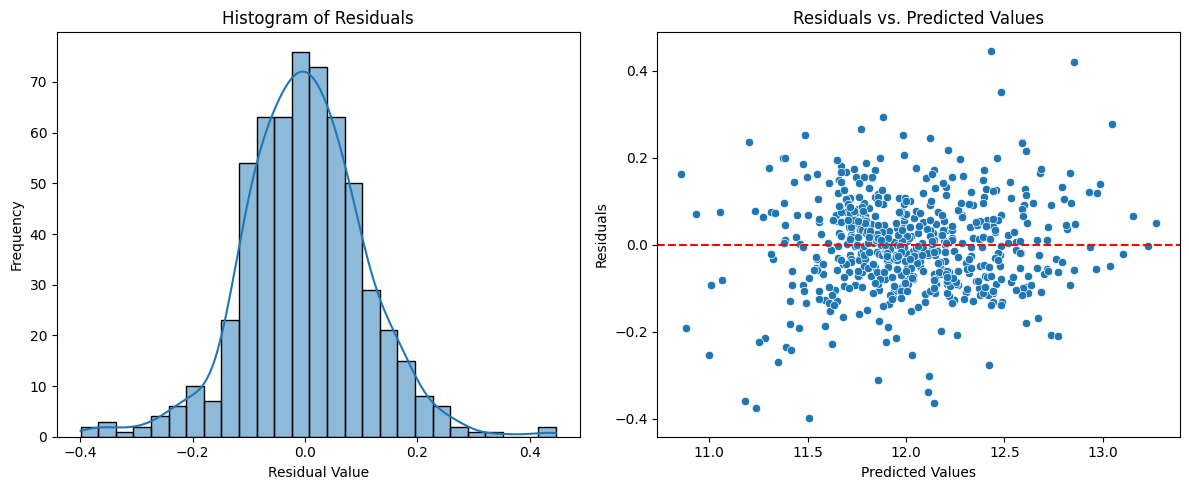

In [ ]:
# 1. Classic OLS with Forward Selection
ols_results = run_modeling_workflow(X, y, model_type='ols', selection_direction='forward')

## Handling Multicollinearity with Ridge Regression (L2 Regularization)

**Ridge Regression** is a highly effective machine learning technique designed to rescue models when data suffers from severe **multicollinearity** (when independent variables are highly correlated with one another).

Historical note: Ridge regression was developed in the 1970's and has its roots in Soviet mathematics from the 1940's.

In a standard Ordinary Least Squares (OLS) regression, having overlapping variables—like `Total Bsmt SF` and `Finished Bsmt SF`—causes the math to become highly unstable. The model cannot figure out which variable deserves the "credit" for the prediction, causing the coefficients to swing wildly. A slight change in the training data might cause a coefficient to flip from +50,000 to -50,000.

Ridge regression solves this instability by stepping in and constraining the coefficients, trading a little bit of bias for a massive increase in reliability.

### How Ridge Works: The "Squared Tax" (L2 Penalty)
Like Lasso, Ridge regression modifies the standard OLS math by adding a penalty for model complexity. However, Ridge uses an **L2 Penalty**, which calculates the tax based on the *squared* value of the coefficients.

Because the penalty is squared, Ridge heavily punishes abnormally large coefficients. To avoid this massive tax, the algorithm forces the coefficients to "shrink" toward zero.

Here is the crucial difference between Ridge and Lasso: **Ridge shrinks coefficients asymptotically close to zero, but it never forces them to exactly 0.0.**

The strictness of this shrinkage is controlled by a tuning parameter (usually called **Alpha ($\alpha$)** or **Lambda ($\lambda$)**):
* If $\alpha = 0$, there is no penalty, and Ridge acts exactly like a wild, unstable OLS regression.
* As $\alpha$ increases, the coefficients are squashed closer and closer to zero, shrinking their influence and stabilizing the model.

---

### The Benefits: Why Use Ridge?

* **The Ultimate Cure for Multicollinearity:** Ridge regression thrives when features overlap. Instead of arbitrarily dropping one correlated variable and keeping another (like Lasso does), Ridge smoothly distributes the "credit" among all correlated variables, shrinking them together. This makes the model incredibly stable.
* **Reduces Overfitting (Bias-Variance Tradeoff):** By restricting the size of the coefficients, Ridge prevents the model from overly relying on any single variable. It stops the model from memorizing the "noise" in the training data, resulting in much better long-term prediction accuracy on unseen data.
* **Keeps All Your Variables:** If domain knowledge tells you that every single variable in your dataset is conceptually important to the outcome, Ridge is the ideal choice. It reins in their mathematical impact without deleting them from the equation.

### Limitations of Ridge

* **No Feature Selection (The "Clutter" Problem):** Because Ridge never shrinks a coefficient to exactly absolute zero, it will never drop a variable from your model. If you feed Ridge 200 variables, you will get a final model with 200 variables. It cannot be used to simplify or declutter a dataset.
* **Mandatory Feature Scaling:** Just like Lasso, Ridge penalizes the *size* of the coefficients. Therefore, you must standardize or normalize your data (e.g., using `StandardScaler`) before running the model. If you don't, Ridge will unfairly penalize variables simply because they are measured in small units (like acres vs. square feet).
* **Loss of Traditional Interpretability (Biased Slopes):** Because Ridge artificially squashes the coefficients to stabilize the model, you can no longer interpret the slopes literally. A Ridge coefficient of \$40 for `Square Feet` does *not* mean the real-world value is exactly \$40; it is a mathematically biased, shrunken number.
* **Requires Hyperparameter Tuning:** You cannot run a Ridge regression blindly. You must use **Cross-Validation** to test out dozens or hundreds of different $\alpha$ (penalty) values to find the exact sweet spot that minimizes error without flattening the coefficients too much.

--- Running RIDGE Cross-Validation on Training Data ---
--- Model Evaluation (RIDGE) ---
Cross-validated R-squared: 0.8911 ± 0.0178
Cross-validated MSE:       0.0179 ± 0.0043

Intercept: 12.0180

Standardized Coefficients (using Ridge Regularization | alpha=10.0):
	MS SubClass          :	    0.00
	Lot Frontage         :	    0.01
	Lot Area             :	    0.02
	Overall Qual         :	    0.12
	Overall Cond         :	    0.06
	Year Built           :	    0.07
	Year Remod/Add       :	    0.02
	BsmtFin SF 1         :	    0.01
	BsmtFin SF 2         :	   -0.00
	Bsmt Unf SF          :	   -0.02
	Total Bsmt SF        :	    0.07
	1st Flr SF           :	    0.04
	2nd Flr SF           :	    0.04
	Gr Liv Area          :	    0.08
	Bsmt Full Bath       :	    0.01
	Full Bath            :	    0.01
	Half Bath            :	    0.00
	Bedroom AbvGr        :	   -0.01
	TotRms AbvGrd        :	    0.00
	Fireplaces           :	    0.02
	Garage Yr Blt        :	    0.01
	Garage Cars          :	    0.02
	Garage A

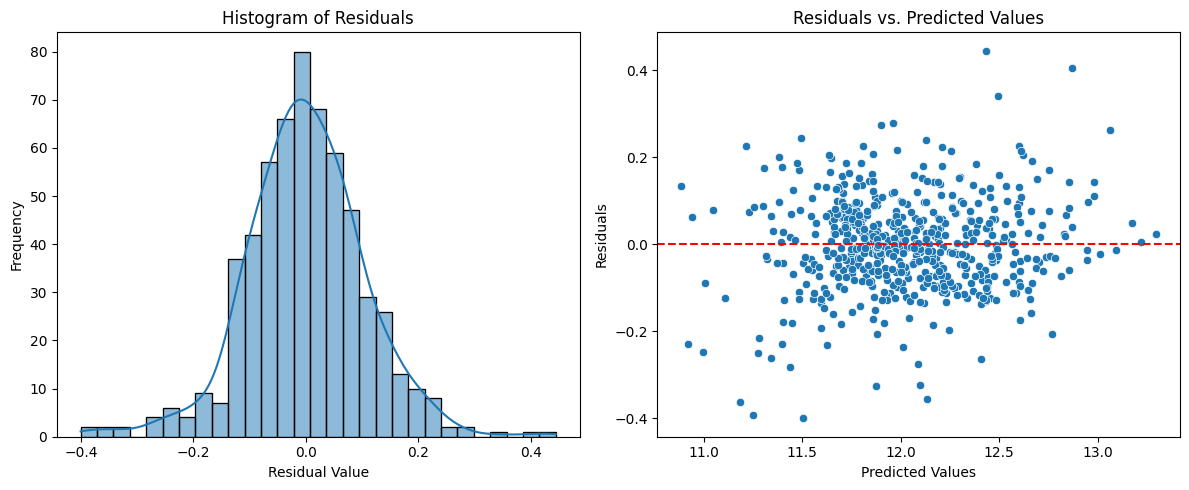

In [ ]:
# Ridge Regression (Shrinks coefficients, drops nothing)
ridge_results = run_modeling_workflow(X, y, model_type='ridge', alpha=10.0)

## Feature Selection with Lasso Regression (L1 Regularization)

**LASSO** (Least Absolute Shrinkage and Selection Operator) serves as a modern, mathematically elegant alternative to step-by-step methods like Forward Selection. It is specifically designed to tackle datasets with too many predictors and severe multicollinearity.

Historical note: Invented by Robert Tibshirani in 1996.

While Ordinary Least Squares (OLS) regression focuses entirely on finding the line that minimizes the error between predictions and actual values, OLS has no concept of "simplicity." If you give OLS 100 variables, it will use all 100 variables—even if they are redundant—often leading to overfitting (a model that memorizes the training data but performs poorly on new, unseen data).

Lasso fixes this by introducing a penalty for complexity.

### How Lasso Works: The "Coefficient Tax"
Lasso regression starts by giving the model access to every possible predictor. However, it changes the fundamental math of the regression. In addition to minimizing prediction errors, Lasso applies an **L1 Penalty**—a mathematical "tax" based on the absolute value of the model's coefficients.

To lower this tax, the algorithm is forced to shrink the coefficients of less useful variables. Because of the specific way the L1 penalty is calculated, Lasso doesn't just shrink these coefficients close to zero; it forces the coefficients of weak or redundant variables to exactly 0.0.

The strength of this tax is controlled by a tuning parameter (usually called **Alpha ($\alpha$)** or **Lambda ($\lambda$)**).
* If $\alpha = 0$, there is no tax, and Lasso acts exactly like a standard OLS regression.
* If $\alpha$ is very high, the tax is so strict that the model may drop all of the predictors.

---

### Benefits of Lasso

* **Automatic Feature Selection:** Unlike Ridge regression (which shrinks coefficients but keeps them all), Lasso acts as a ruthless editor. By pushing coefficients to absolute zero, it completely removes noisy or useless variables from the model, resulting in a cleaner, highly interpretable equation.
* **Solves Multicollinearity:** If you feed Lasso two variables that represent the exact same thing (like `Total Bsmt SF` and `Finished Bsmt SF`), Lasso handles the multicollinearity for you. It will usually pick the slightly better predictor and drop the redundant one to zero.
* **Reduces Overfitting (The Bias-Variance Tradeoff):** By simplifying the model and ignoring the "noise" in the training data, Lasso intentionally trades a tiny bit of accuracy on the training data (introducing bias) to achieve a massive improvement in predicting *new, unseen* data (reducing variance).

### Limitations of Lasso

* **Mandatory Feature Scaling:** This is the biggest trap for beginners. Because Lasso penalizes the *size* of the coefficients, it is entirely dependent on the scale of your data. (For example, the coefficient for `Square Feet` will naturally be much smaller than the coefficient for `Number of Kitchens`). You must standardize or normalize all of your features before running Lasso, otherwise, the penalty will unfairly eliminate variables simply because they are measured in larger units.
* **Arbitrary Selection Among Correlated Variables:** While Lasso is great at handling multicollinearity, its method is somewhat arbitrary. If two features are highly correlated, Lasso will essentially pick one at random to keep and drop the other. This can be frustrating if it drops a variable that makes more logical sense for human interpretation.
* **Loss of Traditional Interpretability (Biased Slopes):** In standard OLS, a coefficient of $50 means "every unit adds exactly $50." Because Lasso *shrinks* coefficients to pay its penalty tax, the remaining coefficients are mathematically biased (lower than their true real-world value). You cannot interpret Lasso coefficients as pure real-world slopes.
* **Requires Hyperparameter Tuning:** You cannot just run Lasso once. You have to find the "Goldilocks" penalty size ($\alpha$)—not too weak, not too strict. This requires writing additional code to run **Cross-Validation**, testing dozens of different penalty sizes to find the one that builds the most accurate model.

--- Running LASSO Cross-Validation on Training Data ---
--- Model Evaluation (LASSO) ---
Cross-validated R-squared: 0.8865 ± 0.0199
Cross-validated MSE:       0.0186 ± 0.0048

Intercept: 12.0180

Standardized Coefficients (using Lasso Regularization | alpha=0.01):
	MS SubClass          :	   -0.00  <-- Dropped
	Lot Frontage         :	    0.00
	Lot Area             :	    0.01
	Overall Qual         :	    0.12
	Overall Cond         :	    0.04
	Year Built           :	    0.07
	Year Remod/Add       :	    0.02
	BsmtFin SF 1         :	    0.04
	BsmtFin SF 2         :	    0.00  <-- Dropped
	Bsmt Unf SF          :	   -0.00  <-- Dropped
	Total Bsmt SF        :	    0.04
	1st Flr SF           :	    0.00
	2nd Flr SF           :	    0.00  <-- Dropped
	Gr Liv Area          :	    0.12
	Bsmt Full Bath       :	    0.01
	Full Bath            :	    0.00  <-- Dropped
	Half Bath            :	    0.00  <-- Dropped
	Bedroom AbvGr        :	   -0.00  <-- Dropped
	TotRms AbvGrd        :	    0.00  <-- Dropped
	Fir

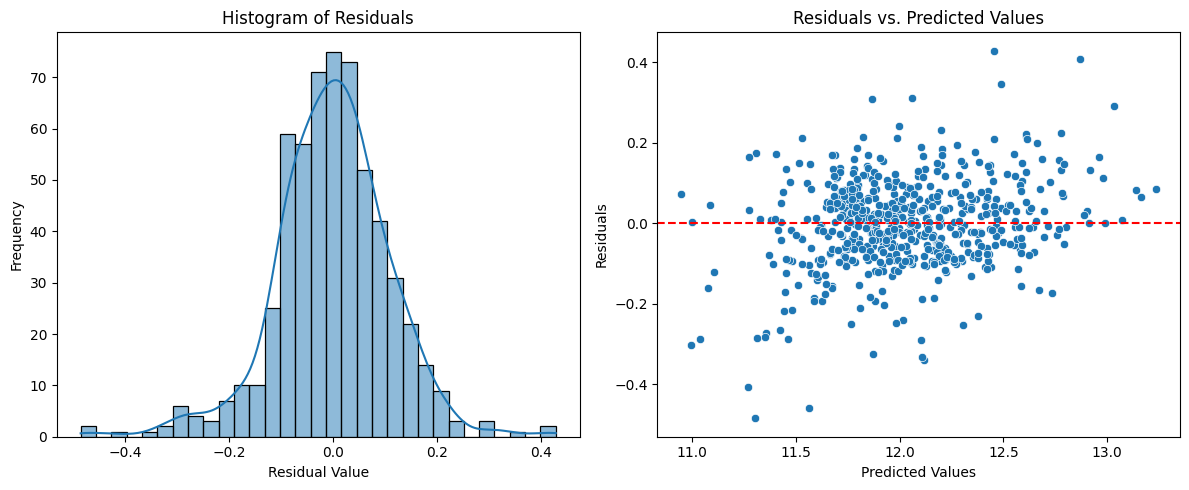

In [ ]:
# Lasso Regression (Shrinks coefficients, drops redundant features to 0.0)
lasso_results = run_modeling_workflow(X, y, model_type='lasso', alpha=.01) # turn up alpha to increase the penalty and reduce features

## Elasticnet

ElasticNet combines both the L1 and L2 penalties.  

If you have two variables that measure almost the exact same thing (like `Total Bsmt SF` and `Finished Bsmt SF`):
* **Lasso** will essentially flip a coin, keeping one variable and forcing the other to exactly zero. This is great for simplifying the model, but it loses information and can drop a variable you actually care about.
* **Ridge** will shrink both variables together smoothly, creating a highly stable model. But it will never force a coefficient to zero, meaning you are stuck with every single variable you started with.

ElasticNet Regression mathematically combines both Lasso and Ridge to get the best of both worlds.

### How ElasticNet Works: The "Combo Tax"
Instead of choosing between the L1 penalty (absolute value) or the L2 penalty (squared value), ElasticNet applies *both* taxes at the same time.

Because it uses both penalties, it introduces a new concept: the **Mixing Parameter** (often called the `l1_ratio`). This allows you to slide a dial between Ridge and Lasso to find the perfect blend.
* An `l1_ratio` of 1.0 means it is 100% Lasso.
* An `l1_ratio` of 0.0 means it is 100% Ridge.
* An `l1_ratio` of 0.5 means the penalty is split 50/50 between the two methods.



### Benefits of ElasticNet

* **The "Group Effect" (Best of Both Worlds):** This is ElasticNet's superpower. When it encounters a group of highly correlated variables, it doesn't arbitrarily kill all but one (like Lasso). Instead, it acts like Ridge: it keeps the whole group and shrinks their coefficients together. But, if a variable is completely useless, it acts like Lasso: it pushes that specific coefficient to exactly 0.0 and removes it.
* **Handles Massive Datasets:** If you have a dataset where you have more columns (predictors) than you have rows (observations), standard regression and Lasso mathematically break down. ElasticNet handles this flawlessly, making it a favorite in fields like genetics.
* **Ultimate Flexibility:** Because you control the mix of L1 and L2, ElasticNet guarantees that your model will perform at least as well as Ridge or Lasso, because it can simply become one of them if that is what the data requires.

### Limitations of ElasticNet

* **Double the Hyperparameter Tuning:** This is the biggest cost of ElasticNet. With Ridge or Lasso, you only had to test one parameter: the size of the penalty ($\alpha$). With ElasticNet, you have to test two parameters simultaneously: the size of the penalty ($\alpha$) AND the mix between L1/L2 (`l1_ratio`). This requires a 2D "Grid Search" during Cross-Validation, which takes significantly more computing time.
* **Mandatory Feature Scaling:** Just like Ridge and Lasso, ElasticNet applies a penalty based on the size of the coefficients. You must standardize or normalize your data before running it, or the math will unfairly penalize variables on larger numerical scales.
* **Biased Slopes:** Because the coefficients are shrunken to stabilize the model, they lose their literal, real-world interpretation. You cannot say "an extra square foot adds exactly $50" because the coefficient has been artificially compressed.
* **Still a Linear Model:** While ElasticNet is often the best possible linear model you can build, it still assumes relationships are straight lines. If your data involves complex thresholds or deep interactions, you will eventually need to graduate to non-linear Machine Learning (like Random Forests or Gradient Boosting).

### Historical Note
* Invented by Hui Zou and Trevor Hastie in 2005.
* Historical Context: After a decade of using Lasso, researchers figure out a way to address Lasso's primary flaw; when faced with a group of highly correlated variables, Lasso would arbitrarily pick one and drop the rest. In fields like genetics, dropping correlated genes was problematic because all of them were part of the same biological pathway. Zou and Hastie merged Ridge and Lasso math together to create ElasticNet, giving researchers a tool that could select features (like Lasso) but keep correlated groups together (like Ridge).

### Modern Usage Note:

If data scientists purely care about predictive accuracy, they generally abandon linear models entirely at this stage and move on to tree-based models (like Random Forests or XGBoost).

However, ElasticNet remains the state-of-the-art for *interpretable* machine learning. It is popular in fields like bioinformatics, genomics, and econometrics where you have highly correlated features, or where you have more variables than rows of data (e.g., 10,000 genes but only 500 patients). It gives you the feature selection of Lasso with the stability of Ridge.

--- Running ELASTICNET Cross-Validation on Training Data ---
--- Model Evaluation (ELASTICNET) ---
Cross-validated R-squared: 0.8899 ± 0.0191
Cross-validated MSE:       0.0181 ± 0.0046

Intercept: 12.0180

Standardized Coefficients (using Elasticnet Regularization | alpha=0.01, l1_ratio=0.5):
	MS SubClass          :	   -0.00  <-- Dropped
	Lot Frontage         :	    0.01
	Lot Area             :	    0.02
	Overall Qual         :	    0.12
	Overall Cond         :	    0.05
	Year Built           :	    0.07
	Year Remod/Add       :	    0.02
	BsmtFin SF 1         :	    0.03
	BsmtFin SF 2         :	    0.00  <-- Dropped
	Bsmt Unf SF          :	   -0.00  <-- Dropped
	Total Bsmt SF        :	    0.04
	1st Flr SF           :	    0.01
	2nd Flr SF           :	    0.00  <-- Dropped
	Gr Liv Area          :	    0.12
	Bsmt Full Bath       :	    0.01
	Full Bath            :	    0.00  <-- Dropped
	Half Bath            :	    0.00  <-- Dropped
	Bedroom AbvGr        :	   -0.00  <-- Dropped
	TotRms AbvGrd       

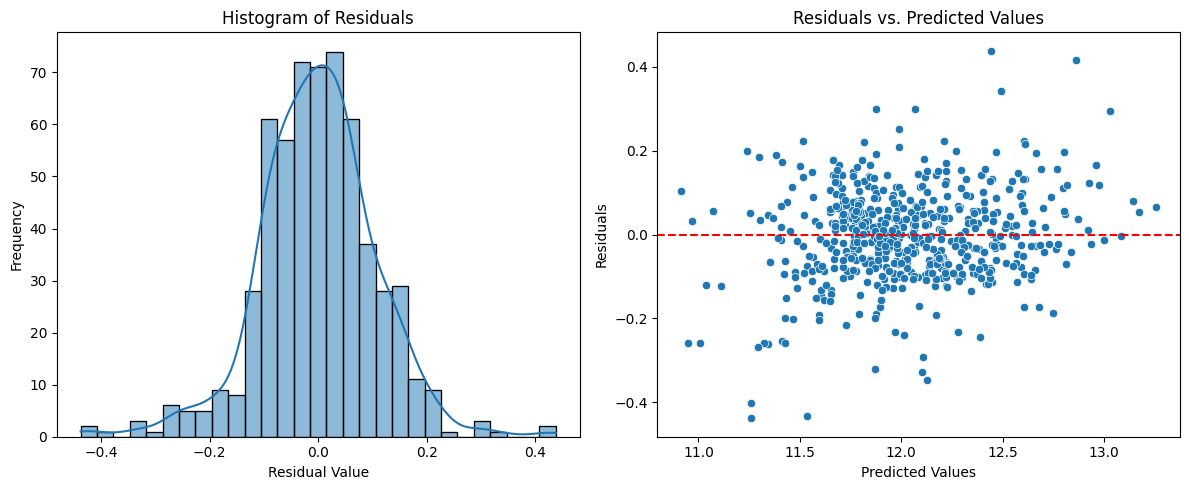

In [ ]:
# 4. ElasticNet (The 50/50 compromise between Ridge and Lasso)
enet_results = run_modeling_workflow(X, y, model_type='elasticnet', alpha=.01, l1_ratio=0.5)

## Model Comparison Summary

Let's compare all four approaches side-by-side:

In [ ]:
# Create a comparison table
comparison_data = {
    'Model': ['OLS (Forward Selection)', 'Ridge (α=10.0)', 'Lasso (α=0.01)', 'ElasticNet (α=0.01, l1=0.5)'],
    'CV R² (mean ± std)': [
        f"{ols_results['cv_r2_mean']:.4f} ± {ols_results['cv_r2_std']:.4f}",
        f"{ridge_results['cv_r2_mean']:.4f} ± {ridge_results['cv_r2_std']:.4f}",
        f"{lasso_results['cv_r2_mean']:.4f} ± {lasso_results['cv_r2_std']:.4f}",
        f"{enet_results['cv_r2_mean']:.4f} ± {enet_results['cv_r2_std']:.4f}"
    ],
    'CV MSE (mean ± std)': [
        f"{ols_results['cv_mse_mean']:.4f} ± {ols_results['cv_mse_std']:.4f}",
        f"{ridge_results['cv_mse_mean']:.4f} ± {ridge_results['cv_mse_std']:.4f}",
        f"{lasso_results['cv_mse_mean']:.4f} ± {lasso_results['cv_mse_std']:.4f}",
        f"{enet_results['cv_mse_mean']:.4f} ± {enet_results['cv_mse_std']:.4f}"
    ],
    'Test R²': [
        f"{ols_results['final_r2']:.4f}",
        f"{ridge_results['final_r2']:.4f}",
        f"{lasso_results['final_r2']:.4f}",
        f"{enet_results['final_r2']:.4f}"
    ],
    'Features Kept': [
        len(ols_results['selected_features']),
        len(ridge_results['selected_features']),
        len(lasso_results['selected_features']),
        len(enet_results['selected_features'])
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

## Conclusions

### Key Takeaways:

1. **All models perform similarly** - The CV R² values are all around 0.89, showing that regularized regression doesn't dramatically improve prediction accuracy on this dataset.

2. **OLS with Forward Selection** works well when you need interpretability and want to know exactly which features were selected.

3. **Ridge** is useful when you suspect multicollinearity and want to keep all features while shrinking their coefficients. It provides stability but doesn't perform feature selection.

4. **Lasso** automatically performs feature selection by driving coefficients to zero. It's ideal when you suspect many features are irrelevant or redundant.

5. **ElasticNet** offers a compromise - it can keep groups of correlated features together while still dropping truly useless ones.

### When to Use Each Method:

| Scenario | Recommended Method |
|----------|-------------------|
| Few features, clear relevance | OLS Forward Selection |
| Many correlated features, want all kept | Ridge |
| Many irrelevant features, want simplicity | Lasso |
| Many correlated + irrelevant features | ElasticNet |
| More features than samples (p > n) | ElasticNet |